# **Linear Algebra for ML**

## **Introduction: Why Linear Algrebra matters in Data Work**
Linear Algebra in practice refers to using mathematical tools such as
eigen decomposition, singularvalue decomposition (SVD), and principal component analysis (PCA) to analyze and transformdatasets. These tools help us understand structure, compress data, and extract meaningful patterns.

## **Why this matters?**
Real-world data is often large, messy, and high-dimensional. Working with it directly is inefficientand often misleading.

## **Foundation: Core Concepts Explained:**

## **Concept A: Eigen decomposition:**
* Eigen decomposition splits a matrix into its eigen values and eigen vectors, which tell us the important directions and how much variance lies in each.
* If you push a spring from different angles, it may stretch more easily in one direction — that directionis the eigenvector, and the amount it stretches is the eigenvalue.
* Eigen vectors are special because becausemultiplying the matrix by an eigenvector does not change its direction.
* Used in stability analysis, vibration modelling, PCA, Markov chains.

## **Concept B: Singular Value Decomposition**
* SVD breaks any matrix into three matrices.
* Intuition: SVD reorganizes data to make the important patterns appear first and the less important ones appearlater.
* Every matrix has an SVD, even when eigen decomposition cannot be applied.
* SVD is used in image compression, noise removal, recommendation systems.

## **Concept C: PCA(Principal Component Analysis):**
* PCA finds directions in data where variance is highest and projects the data into thesedirections to reduce dimensions while retaining meaning.
* It converts many correlated variables into a smaller number of uncorrelated summary variables.

#### Where it is used:
* Used in image compression, recommendation systems, bioinformatics, and facerecognition to reduce dimensionality.
* Helps visualize high-dimensional data meaningfully in 2D or 3D.

## **Concept D: SciPy Linear Algebra(SciPy LA):**
* SciPy's linalg module provides efficient numerical implementations
of matrix decompositions.
* Why use SciPy instead of coding manually?
    * Faster
    * More stable
    * Handles edge cases properly
* Example functions:
    * scipy.linalg.eig — eigendecomposition
    * scipy.linalg.svd — SVD
    * scipy.linalg.inv — matrix inverse

* SciPy LA is like using professional power tools instead of hand tools — the job is the same, butthe execution is faster, safer, and more precise.
* Where it is used:
  * ML model pipelines
  * Optimization and simulation
  * Signal and simulation

## **Concepts in Action:**

#### **Example 1: Eigen decomposition in practice:**
* You have a 2D dataset and want to understand its dominant direction of variation.
> Our approach: Compute eigen values and eigen vectors of the covariance matrix.

In [ ]:
import numpy as np

# Step 1: Create a simple array
X = np.array([[3,1],
              [2,2],
              [4,3],
              [5,4]])

# Step 2: Centre the data
X_centered = X - np.mean(X, axis = 0)

# Step 3: Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar = False)

# Step 4: Eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print(f'Eigen values: {eigen_values}')
print(f'Eigen vectors: {eigen_vectors}')

#### What's happening here:
We find directions in which the dataset varies the most. The eigen vector with the highest eigen value is the dominant trend direction.

#### Key takeaway:
* Eigen decomposition reveals intrinsic structure in data.
* Eigen vectors tell you how the data is shaped.

#### **Example 2: SVD Demo:**
* You have a matrix that may represent user ratings, image pixels, or correlations. You want to uncover the most influential patterns inside it.

> Our approach: Apply SVD to decompose the matrix into its structural components — directions and strengths.

In [ ]:
A = np.array([[4,0],
              [3,-5]])

U, S, Vt = np.linalg.svd(A)

print("U:\n", U, '\n')
print("Singular values:", S,'\n')
print("V^T:\n", Vt)

#### What's happening in the above cell?
* U contains patterns in the rows.
* Vᵀ contains patterns in the columns.
* S shows how strong each pattern is.

#### Key takeaway:
* SVD separates structure from noise — the largest singular values represent the most meaningful patterns.
* SVD works for any matrix, even non-square ones. Eigendecomposition requires a square matrix.

#### **Example 3: PCA (Principal Component Analysis):**
* You have a dataset with many correlated features (for example: height, weight, BMI, body-fat %,muscle mass).
* The dataset feels large and messy, and you want to
reduce it without losing the maininformation.
> Our approach: Use PCA to transform the data into a set of new features (called Principal Components) that:
  * capture the most variance in the data.
  * are uncorrelated.
  * reduce dimensionality while keeping the important structure.

In [ ]:
from sklearn.decomposition import PCA

X = np.array([[2.5, 2.4],
              [0.5, 0.7],
              [2.2, 2.9],
              [1.9, 2.2],
              [3.1, 3.0],
              [2.3, 2.7]])

pca = PCA(n_components = 1)
X_reduced = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)
print("Transformed data:\n", X_reduced)

#### What's happening in the above cell?
* PCA finds the direction in which the data varies the most (the “main trend”).
* It rotates the original coordinate system to align with this trend.
* Then, we drop the less informative directions, compressing the dataset.

* So the model keeps maximum information using fewer features.

#### Key takeaway:
* PCA simplifies data while keeping the important patterns.

#### **Example 4: SciPy Linear Algebra:**
* You need to compute decompositions in a reliable, numerically stable, and fast way — especially on real datasets.
> Our approach: Use scipy.linalg, which wraps optimized
LAPACK/BLAS routines under the hood.

In [ ]:
from scipy.linalg import eig, svd

A = np.array([[2,1],
              [1,2]])

w, v = eig(A)
print(f'Eigen values: {w}')

U, S, Vt = svd(A)
print(f'Singular values: {S}')

#### What's happening in the above cell?
* SciPy calls high-performance compiled routines , avoiding rounding errors and instability common in manual implementations.

#### Key takeaway:
SciPy LA is the preferred tool for professional numerical computing — it is faster, safer, and more accurate than writing your own computations.

## **Introducing a Real-World Problem**

>**Instructor Guidance:**
- Start with the Human Approach
  - Begin by describing how a person would manually approach and solve this problem in a real-world setting — step by step, using observation and logic.
- Highlight the Limitations
  - Discuss the drawbacks of doing this manually — such as the time required, human errors, or inconsistency in decision-making.
- Transition to Automation
  - Then explain how this process can be automated using machine learning or AI, and outline what the end-to-end solution flow would look like.
- Emphasize the Role of Labeled Data
  - Finally, clarify why a model needs labeled examples to learn from — that this data allows the system to recognize patterns and correctly classify new instances (like identifying the right fish species).
  Before we begin unsderstanding more concepts, let's go through a small video: https://www.youtube.com/shorts/pfnH5lJbMLM

Notice how each fish is getting sorted into different buckets.

Inherently, we know that there must be a scanner that analyses certain parameters.

<br>

**What do you think are the parameters based on which the sorting works?**

- Weight
- Size
- Appearance
  - Colour
  - Shape and so on

To solve this automation task we would need the scanner to collect the data send it somewhere (essentially a model), then the model make a prediction using the data and will return the output to the seperator.

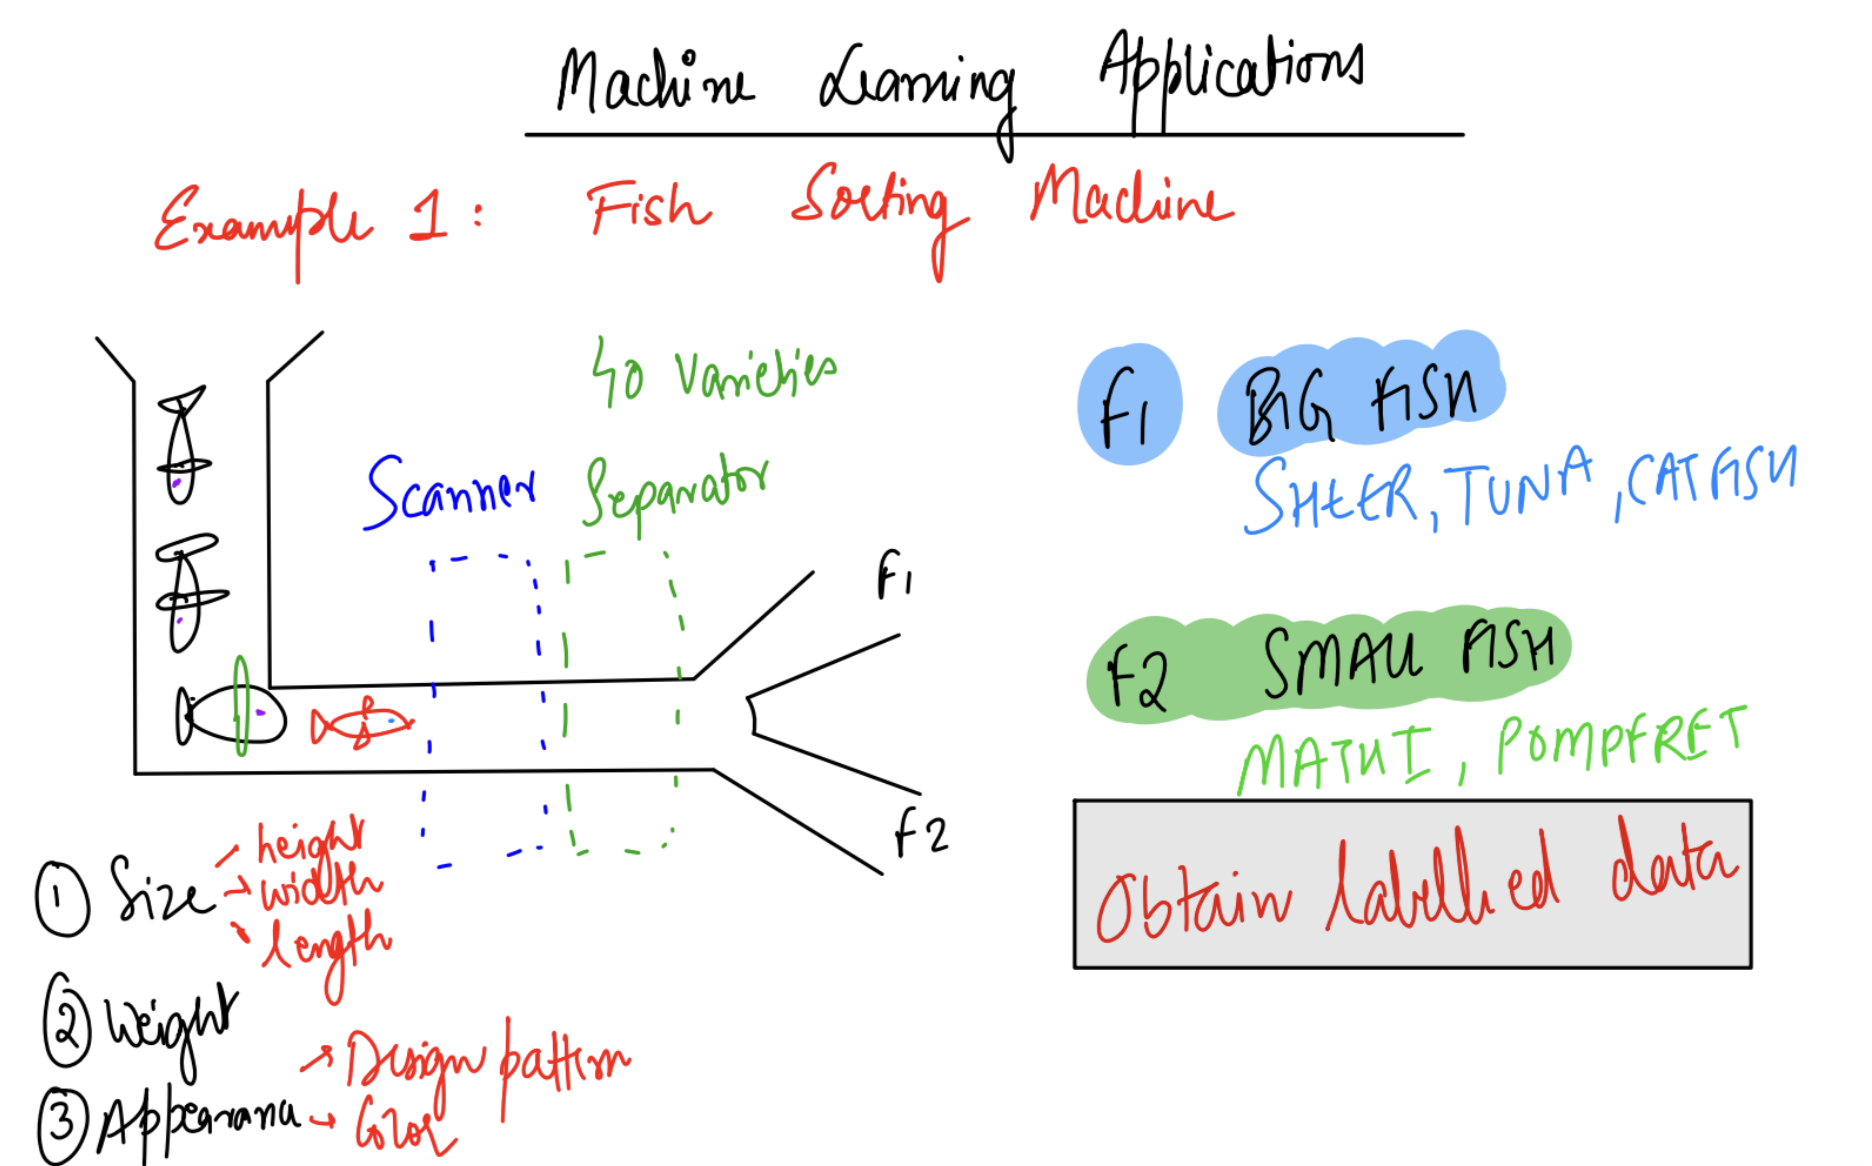

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/045/972/original/Screenshot_2023-09-04_at_3.28.03_PM.png?1693821495)

**What do you call these parameters that help us determine the fish type?**
- It is called **features**.
- They are also referred to as **Independent variable**
- We can record values of each features using a sensor

**And the different type of fish are known as?**
- These are known as **targets** or is also called as **labels** or **Dependent Variable**.
- It tells us which type does a given row belong to

Given a datapoint our job is to predict it's respective Label

#### **Visualizing the data**

>**Attention to detail**
- Start with why are we plotting a scatter plot
- Explain that we can easily seperate 2 different classes using a line
- Explain in **brief** how a line would help us in predcting a new point

So let's take the data that we have and plot them

- Since we have 3 features with us let's pick up 2 features which is height and width and create a scatter plot to understand what is their replationship with each other as well as their combined relationship with the target variable.
- This is a 2-D plot
- As we can see that we can have infinte number lines between green points and the Blue points
<br>

**The question is which is the best line that we should pick that will help us separate Blue points from green points?**
- This is the question that we will be solving in this entier module.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/045/983/original/Screenshot_2023-09-04_at_3.58.54_PM.png?1693823360)

## Process of Builing ML Algorithm

>**Attention to detail**
- Explain points a, b and c using the above covered exmples
  - We will learn about PCA in this module and TSNE in upcoming module
- Touch upon points d and e you can explain in very brief what exactly it is and can convey that it'll be covered in upcoming classes

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/045/993/original/Screenshot_2023-09-04_at_4.33.35_PM.png?1693825433)

## **Coordinate Geomtery**

### Basics of Lines

> **Attention to detail**
- Start with x and y coordinates and explain the equation of lines and explain what term means.
- Using [Desmos](https://www.desmos.com/calculator) and equation of Line demonstrate what m and c are visually and what happen when we keep one constant change other.
- Explain the scenario where we cannot create a line which is perpendicular to x axis and to over come that we'll use the general form of line.

The basic equation of Line is

**y = mx + c**

This is also referred to as **Slope intercept equation** of a Line

- **x** is input and is an indepedent variable
- **m** is slope of the line ie the angle it makes with the x axis
- **c** is the y-intercept
- **y** is the output and is a dependant variable ie it is dependent on x given that we keep m and c contant

For a given point ($x_1$,$y_1$) if it lies on our line $L_1$ it should satisfy the equation of our line and the equation would be

**$y_1=mx_1+C$**

- The slope **m** can be calculated by calculating **$tan \ \theta$ = $\frac{y_2 - y_1}{x_2 - x_1}$**, where $(x_1, y_1) \ (x_2, y_2)$ are two coordinates on the line.

- Range of $tan \ \theta$ is from -$\infty$ to $\infty$
- $tan(90)$= $\infty$ due which there is a limitation which is using the slope intercept form we cannot create a line which is 90 degrees to x-axis and to overcome this we use general form of line

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/001/original/Screenshot_2023-09-04_at_4.51.22_PM.png?1693826495)

### **General form of Line**

We might have already studied this form which is

**Ax+By+c=0**

- Now here instead of using A and B we are using $W_1$ and $W_2$
  - In the ML context they are referred to as `weights` that the computer learns
- Instead of x and y we use $x_1$ and $x_2$ they both mean the same thing that it has 2 Dimensions
  - In the ML context they are referred to as `features` which we saw above line legth, weight,etc.
- C is represented as $W_0$
  - In the ML context this is referred to as `Bias`
- We are essentally changing the way it is represented that is because we follow this form of representation in Machine learning and the terminologies changes when we go to the Machine learning side of representation

We can convert general form of line into slope intercept form.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/026/original/Screenshot_2023-09-04_at_5.20.00_PM.png?1693828216)

### Parallel lines
If 2 lines are parallel to each other then they will have same angle with the x-axis which means that both the lines will have same slopes

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/033/original/Screenshot_2023-09-04_at_5.50.27_PM.png?1693830043)

### Perpendicular Lines
- The product of the slopes of 2 perpendicular lines is equal to -1
- if slope of line1 is $m_1$ and slope of line2 is $m_2$ then the formula to represent slope of 2 perpendicular lines is
$m_1*m_2=-1$ which is equal to $m_1=-\frac{1}{m_2}$
- using the general form we have

$-\frac{w_1}{w_2}*-\frac{w_3}{w_4}=-1$

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/036/original/Screenshot_2023-09-04_at_5.54.55_PM.png?1693830314)

### More than 2 dimensions

How can we take the general form of line and expand it to higher dimensions that is till n dimensions?

So this is called as the **Generalized equation of a line**

- 2D it is a Line
- 3D it is a plane
- 4D it is 4D hyperplane
- nD it is a nD hyperplane

The term hyperplanes because we cannot visualize beyound 3D

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/038/original/Screenshot_2023-09-04_at_6.07.51_PM.png?1693831088)

## Halfspaces Intro

When we draw a line we can see that we are esentially diving the 2D space into 2 differnet spaces
- one which lies above the line
- other is the one that lies below the line

Similarly in 3D we can divide the space into 2 parts using a Plane
- One which lines above the plane
- other is one that lies below the plane

And we can extend this concept till n dimensions

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/040/original/Screenshot_2023-09-04_at_6.16.09_PM.png?1693831587)

**Why do we care about halfspaces?**
- Whenever we are asked to classify a new datapoint we just plot the given datapoint and see in which half space does it belong to using which we can classify the given point.
- More on this we'll be clearing in the next class

## Use case: Orange vs Tangerine

Now suppose this is our usecase, to classify the fruits based on their distinct characteristics

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/030/385/original/fruits.csv?1680749521 -O fruits.csv

In [ ]:
import pandas as pd
df = pd.read_csv('fruits.csv')
df.head(10)

Q. What are the features in this dataset?
- Weight, Diameter and color

Q. What do you call the column **fruit**
- Target variable

Q. How many classes do we have and which type of ML problem it is?
- We have 2 classes and it is a binary classification task

In [ ]:
# Let's plot and see what the data looks like

import matplotlib.pyplot as plt

import seaborn as sns
plt.figure()
sns.scatterplot(x='weight', y = 'diameter', hue='fruit', data=df)
sns.lineplot(x = [1,2,5,6], y = [1,2,5,6], color = 'red')
plt.show()

**How do we find the best line from these?**

- If you notice, the clusters can be defined as
  - High diameter, low weight: Orange
  - Low diameter, high weight: Tangerine

Q. Based on this, can the 'Red' be considered a good decision boundary?


Notice, we are always given the x value ie we'll be getting this from the dataset. So now, we need to find the line's m and c?

Let's try to find the value of these parameters and classify the above points using a small simulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive

def plot_line(m, c):
    x = np.linspace(2, 5, num=100)  # generate x values
    y = m*x + c  # calculate y values
    # plt.plot(x, y)  # plot the line
    sns.scatterplot(x='weight', y = 'diameter', hue='fruit', data=df)
    plt.plot(x, y)  # plot the line
    # plt.ylim(-50, 50)  # set y-axis limits
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'y = {m}x + {c}')
    plt.show()

interactive_plot = interactive(plot_line, m=(-1, 5, 0.1), c=(-5, 5, 1))
interactive_plot


Notice, for
- m = 1.7
- c = -2

We are able to find a good enough line to separate both the orange and blue poitns clusters

But do we need to always randomly try out the values to find the parameters?

This is where ML comes in. It helps us to calculate these unknown parameters to find the best-fitting line, given the values of x and we'll learn about this in the upcoming class.


https://intuitive-math.club/linear-algebra/spaces

## Vectors

### Intro to vectors

So far we were storing numbers and to store them in python we can create a list, tuple, pandas series, or a numpy array

What is a Vector?
- As per physics vector is something which is a magnitude and direction both
- In terms of coding we can say that it is a collection of numbers which are stored in a particular format like list,etc


**How do we represent a vector?**
- if x was a vector then we represent it as x with a bar on top of it $ \overline{x}$
- or you'll also find at some places that it is represented as an arrow on top $\overrightarrow{x}$

**If we have a vector with d dimensions then how do we represent it?**
- We can represent it as a column vector or as a row vector
- But in Machine learning or Mathematics in general we always take vectors represented in column format

**How do we represent a vector that belongs to D dimensions mathematically?**
- $x \in \mathbb{R}^d $
- In English it is read as x belongs to set of all real numbers in D dimensions

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/913/original/Screenshot_2023-09-07_at_9.05.14_PM.png?1694100930)

#### Visualizing a vector in 2D space
- In this section, it's demonstrated to draw vectors in a 2D space
- And given a vector in 2D space how to represent it as a column vector.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/046/915/original/Screenshot_2023-09-07_at_9.12.22_PM.png?1694101357)

### Magnitude of vectors

Q. We created a vector which starts from origin and ends at a point (x,y) now we want to find out what is the distance of the point from the origin.
- This is also called as the length or magnitude of the vector

Q. Now how do we compute this distance of a point from origin? can you recall any concept we studied in high school maths?
- We can simply apply pythagoras theorem to find this distance.
- thus the distance for 2d vector can be represented as
  - $\sqrt{x^2+y^2}$

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/921/original/Screenshot_2023-09-12_at_12.30.29_PM.png?1694502044)

Q. Now how do we compute the same for a 3 dimensions Vector or let's say a **d** dimension vector?
- We can generalize it as follows
  - $\sqrt{x_1^2+x_2^2...+x_d^2}$

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/922/original/Screenshot_2023-09-12_at_12.33.31_PM.png?1694502227)

### Norm of a vector

All the above that we studied was in the world of maths and physics but we are dealing in the machine learning world so there's a new term that we'll learn for the magintude of the vector.
- In machine learning world it is called as Norm of the vector, it is the same thing it's just that in ML world it has a new terminology
- To represent this norm of vectors we use double pipes 2 on the left and 2 on the right **$\left || x \right ||$**

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/923/original/Screenshot_2023-09-12_at_12.41.12_PM.png?1694502688)

Now there are different types of norm the most important of them is L2 and L1 norm.

L2 norm:
- it is reresented as **$\left || x \right ||_2= \sqrt {x_1^2+x_2^2..+x_d^2}$**
- This is also known as **Eucledian Distance**

L1 norm:
- **$\left || x \right ||_1= \left | x_1\right| +\left | x_2\right|..+\left | x_d\right|$**
- We call this a **Manhattan distance**

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/924/original/Screenshot_2023-09-12_at_12.48.15_PM.png?1694503115)

### Types of distances

Let's try to visualize what each distance's mean geometrically.


**Setting the Context**
- Let's say the grid here represents roads of the Manhattan city and where the lines intersect we call them as road intresctions
- Why manhattan city only it's because it is a well planned city
- So we have A at (1,1) and B at (4,3) so let's say that the bird has to travel from point A to B it can fly above the buildings and reach the point B.
- But what about human beings they can fly right? so for us we'll travell acorss the road which is first we travel 3 units to the right and then 3 units to the top to reach the point (4,3).
  - **Note:** There are different ways in which we could reach point B but for now were are going with this one.


**Eucledian Distace**
- It is the shortest distance between 2 points
- And it is defined as $\sqrt{(y_2-y1)^2+(x_2-x_1)^2}$

**Manhattan Distance**
- It is nothing but the distance along the grid shaped roads on 2D plane
- And is defined as $\left|y_2-y_1 \right| + \left|x_2-x_1 \right| $

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/925/original/Screenshot_2023-09-12_at_1.13.04_PM.png?1694504599)

## Matrix Multiplication

- Basics on Matrix multiplcation like what are the rules that we need to check when performing a matrix multiplcaition
- then how to multiply both the matrix to get the resultant matrix.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/927/original/Screenshot_2023-09-12_at_1.19.53_PM.png?1694505005)

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/929/original/Screenshot_2023-09-12_at_2.07.05_PM.png?1694507841)

In [ ]:
# matrix multiplication
import numpy as np

a = [1,2]
b = [5,7]

In [ ]:
a[0], a[1], b[0], b[1]

In [ ]:
# dot product of matrices using for loop

dot_prod = 0
for i,j in zip(a,b):
  print(i,j)
  dot_prod += i*j
dot_prod

In [ ]:
# dot producto using numpy
help(np.dot)

In [ ]:
# dot product using numpy
print(f'Dot product of a and b: {np.dot(a,b)}')

#### Using loan example to understand dot product

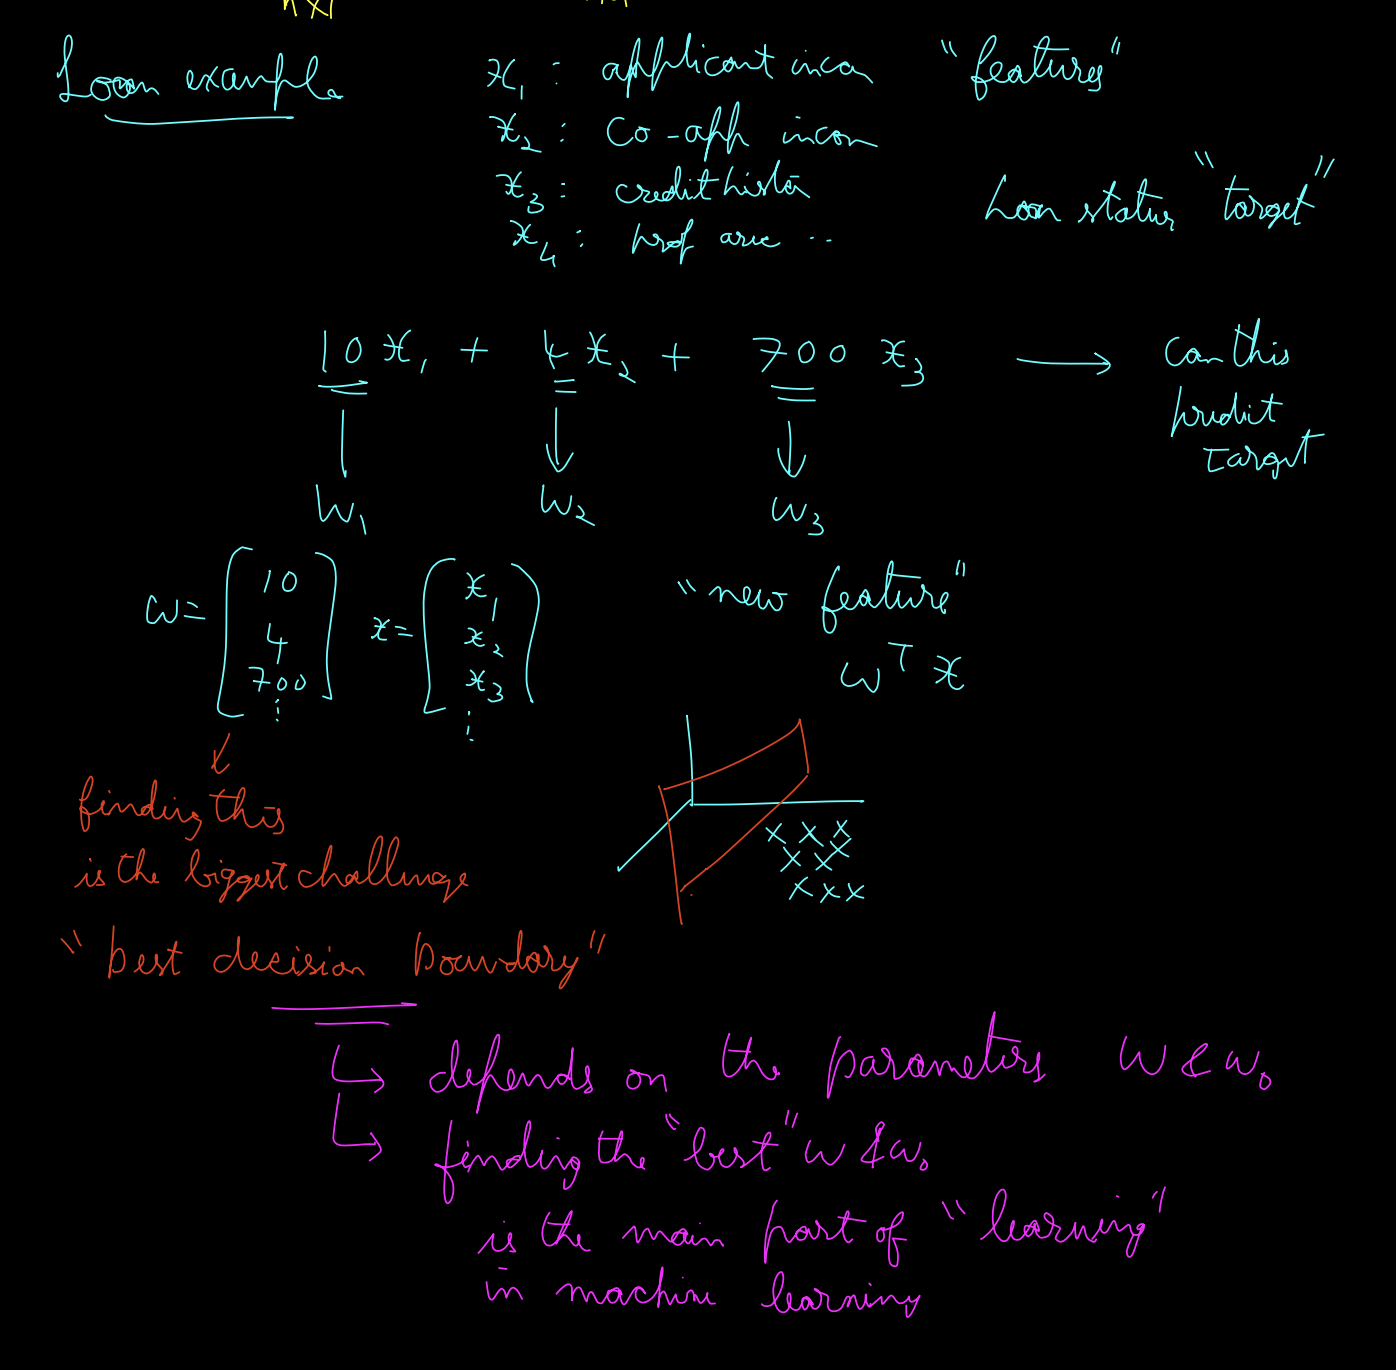

In the loan example, we must have done something like
$10x_1+4x_2+700x_3 -> target$

In this case, 10, 4 and 700 are the w1, w2 and w3 respectively, and their vector will be [10,4,700]

Taking this as **w** and [x1, x2, x3] as **x**

$w^Tx$ = $10x_1+4x_2+700x_3$

- Our aim will be to find this **w** vector in such a way that we get the "best decision boundary"

- The **learning** part in Machine Learning refers to finding this **w** vector

## Angle between two vectors

To calculate the angle between 2 vectors x and y we take $cos(\theta)$
- $cos(\theta)=\frac{\bar{x}^T\bar{y}}{\left||\bar{x}\right||\space \left||\bar{y}\right||}$
- here x and y are both vectors and not individual coordinate points
- $\theta$ is the angle between vector x and y

Now let's divide the 2d surface into 4 quadrants and based on the angle ie $cos(\theta)$ we can conclude as follows
- If $cos(\theta)$ value is greater than 0 then we can say that $\theta$ varies from 0 to 90 degrees or from 270 to 360 degrees.
- If $cos(\theta)$ value is less than 0 then we can say that $\theta$ varies from 90 to 270 degrees.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/931/original/Screenshot_2023-09-12_at_2.16.25_PM.png?1694508634)

**Q. Why do we care about the angle between 2 vectors?**
- We'll learn in detials why sign of dot product is important for now we can say that it'll help us understand where does a given vector lie ie in which quadrant with respect to other vector.


**`You can cover this briefly`**

**Q. When we get a new point, how do we decide whether it lies in the positive or negative halfspace?**
- If we look at the cosine graph, from 90-270 it lies in the negative y-axis.
- So based on the angles, we can find the position of the new point

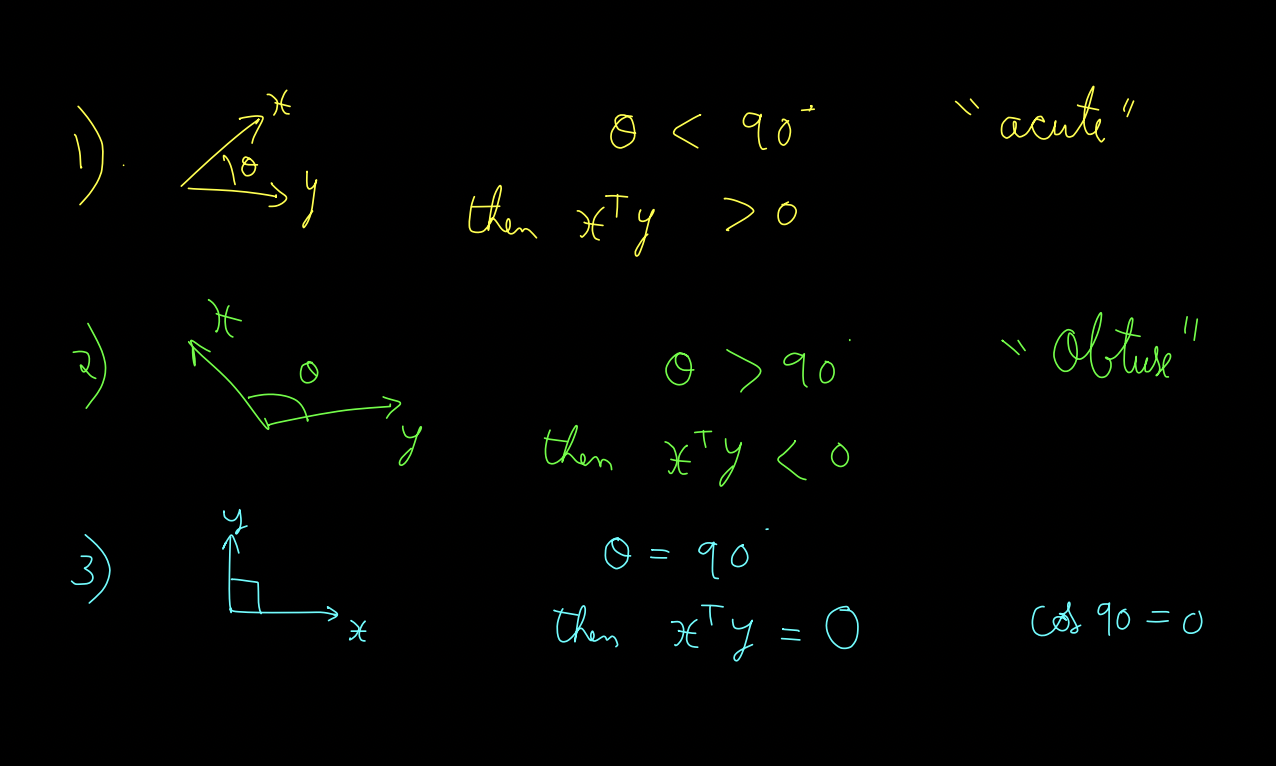

## Connection between coordinate geometry and Linear algebra

When we write **$w_1x_1+w_2x_2=w_0=0$** this is in coordinate geometry
but now if we have to write this equation for d dimensions then it will become a very long equation

Instead of this we create a neat hack which is as follows
- We store all the weight parameters together thus create a **weight vector** for us we denote this as captial W with a bar ie. $\bar{W}$
- Similarly we can store all the x's as a single column vector and we denote this as lower case x ie $\bar{x}$
  - In Machine learning terms we call this as **Feature vector**

Notice that so far we have been using small case but since we are representing all the parameters as a single vector we denote it as a Upper case letter for the weight vector.
- **$\bar{W}^T\bar{x}+w_0=0$**

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/938/original/Screenshot_2023-09-12_at_4.37.25_PM.png?1694516861)

Now let's say we have an eqaution of a line which is $w_1x_1+w_2x_2+w_0=0$

Q. For this above equation what is the weight vector?
- [1, 1] represented in column format

Q. The feauture vector is?
  - [$x_1$,$x_2$] represented in column format

Q. Can we express this equation of line in terms of vector format that we saw above yes or no?
- Yes we can represent it as $W^Tx=w_0=0$

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/939/original/Screenshot_2023-09-12_at_4.43.11_PM.png?1694517207)

Our weight vector is [1,1] so we can represent this as a vector starting from origin and going til (1,1)

Now we can extend this line in magnitude keeping the direction same we can see that the weight vector is perpendicular to the equation of the line
- Thus point to remember is that the weight vector will always be perpendicular to the hyperplane

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/940/original/Screenshot_2023-09-12_at_4.48.54_PM.png?1694517550)

Q. Is the weight vector always going to be perpendicular to the hyperplane?
- The weight vector will always be perpendicular to the hyperplane.

**Let's see this**

Let's say that we have a equation of line which is $x_1+x_2=0$
- here weight vector is [1,1] and $w_0$ is equal to 0
  - in vector notation terms we can represent it as $\bar{w}^Tx=0$
- Let say we also have a vector x which is sitting on our line as show below and $\theta$ is the angle between the weight vector and vector x
  - to find the angle between 2 vector we use the $cos(\theta)$ formula and we also know that $\bar{w}^Tx=0$ if we replace this in the numerator we get $cos(\theta)=0$
  - We know that $cos(\theta)$ is 0 when the angle is 90 or 270 degrees
  - Using this we have proved geometrically that weight vector is perpendicular to our line.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/941/original/Screenshot_2023-09-12_at_5.02.47_PM.png?1694518381)

## Unit vector

- These are vectors with direction but having magintude as 1
- they help us find the direction of a vector

Let say we have a vector [$w_1$,$w_2$] now to find the unit vector of this vector we divide the vector by it's magnitude
- we define this unit vector as w with a hat or cap over it $\hat{w}$
- we can compute this as [$\frac{w_1}{\sqrt{w_1^2+w_2^2}}$,$\frac{w_2}{\sqrt{w_1^2+w_2^2}}$]
- Now to find the magintude of this $\hat{w}$ vector we compute the norm of the vector which will yield us 1 thus proving that $\hat{w}$ is a unit vector with magintude=1 and a ceratain direction to it.

## Basic Trignometry

> Instructor note:
- You can cover this briefly so that everyone is on the same page.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/944/original/Screenshot_2023-09-12_at_5.17.44_PM.png?1694519278)

## Vector projection

Here we'll learn about projection of a vector onto another vector

we have two vectors x and y as shown and we want to find what is the length of the shadow that x casts on to the vector y when the sun is at the very top of the vector x.
- To find this we draw a perpendicular line from the tip of the x vector and compute the length of the shadow that x casts onto y
- we call this shadow as **projection** and we say that we want to find the **length of projection of vector x on to y**
- let's denote this as another vector called as p now our task is to find the length of P vector in terms of x and y vectors.

![](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/047/946/original/Screenshot_2023-09-12_at_5.25.41_PM.png?1694519759)